# Brent Oil Change Point Analysis
This notebook follows the Task 2 outline: acquire Brent spot prices, document exploratory diagnostics, fit a baseline Bayesian change point model in PyMC, and stash artifacts needed downstream for API/dashboard integration.

In [ ]:
import os
import time
from pathlib import Path
from datetime import datetime, UTC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az

# Matplotlib setup
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = Path("../data").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {Path.cwd()}")
print(f"Data directory: {DATA_DIR}")

Working directory: c:\Users\alexo\Desktop\File\10Academy\week11\Github\notebooks
Data directory: C:\Users\alexo\Desktop\File\10Academy\week11\Github\data


## 1. Acquire Brent price history from FRED
Use `pandas_datareader` to pull the `DCOILBRENTEU` series (daily Brent spot), enforce a `DatetimeIndex`, and forward-fill small gaps so downstream modeling sees a continuous series.

In [ ]:
SERIES_ID = "DCOILBRENTEU"
FRED_URL = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={SERIES_ID}"
START_DATE = "1987-05-20"
END_DATE = "2022-09-30"
CACHE_PATH = DATA_DIR / "raw_brent_fred.csv"

raw_prices = None
last_exc = None
for attempt in range(5):
    try:
        raw_prices = pd.read_csv(FRED_URL)
        raw_prices.to_csv(CACHE_PATH, index=False)
        print(f"Fetched fresh data from FRED on attempt {attempt + 1} and cached to {CACHE_PATH.name}.")
        break
    except Exception as exc:
        last_exc = exc
        wait = 2 ** attempt
        print(f"Attempt {attempt + 1} failed ({exc}); retrying in {wait}s...")
        time.sleep(wait)
else:
    if CACHE_PATH.exists():
        print("Falling back to cached download because live fetch failed.")
        raw_prices = pd.read_csv(CACHE_PATH)
    else:
        raise last_exc

raw_prices.columns = raw_prices.columns.str.replace("\ufeff", "").str.strip()
col_lower_map = {col.lower(): col for col in raw_prices.columns}
date_key = next(key for key in col_lower_map if "date" in key)
date_col = col_lower_map[date_key]
value_candidates = [col for col in raw_prices.columns if col != date_col]
value_col = next((col for col in value_candidates if col.upper() == SERIES_ID), value_candidates[0])

raw_prices = raw_prices.rename(columns={date_col: "Date", value_col: "Price"})
raw_prices["Date"] = pd.to_datetime(raw_prices["Date"])
raw_prices = raw_prices.set_index("Date").sort_index().loc[START_DATE:END_DATE]

raw_prices["Price"] = pd.to_numeric(raw_prices["Price"], errors="coerce")
missing_before = raw_prices["Price"].isna().sum()
prices = raw_prices.ffill().dropna()
missing_after = prices["Price"].isna().sum()

print(f"Fetched {len(prices):,} daily observations from {prices.index.min().date()} to {prices.index.max().date()}.")
print(f"Missing values before fill: {missing_before}, after fill: {missing_after}")
prices.head()

Fetched fresh data from FRED on attempt 1 and cached to raw_brent_fred.csv.
Fetched 9,228 daily observations from 1987-05-20 to 2022-09-30.
Missing values before fill: 250, after fill: 0


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


## 2. Persist cleaned price series for reproducibility
Store the processed frame to timestamped Parquet and CSV files so the modeling layer and Flask backend can reuse the exact slice without re-querying FRED.

In [ ]:
run_ts = datetime.now(UTC).strftime("%Y%m%d_%H%M%S")
parquet_path = DATA_DIR / f"brent_prices_{run_ts}.parquet"
csv_path = DATA_DIR / f"brent_prices_{run_ts}.csv"

prices.to_parquet(parquet_path, engine="fastparquet")
prices.to_csv(csv_path)

ARTIFACTS = {
    "run_ts": run_ts,
    "parquet": str(parquet_path),
    "csv": str(csv_path),
    "series_id": SERIES_ID,
    "obs": len(prices),
}
ARTIFACTS

{'run_ts': '20260206_140841',
 'parquet': 'C:\\Users\\alexo\\Desktop\\File\\10Academy\\week11\\Github\\data\\brent_prices_20260206_140841.parquet',
 'csv': 'C:\\Users\\alexo\\Desktop\\File\\10Academy\\week11\\Github\\data\\brent_prices_20260206_140841.csv',
 'series_id': 'DCOILBRENTEU',
 'obs': 9228}

## 3. Exploratory diagnostics and early visual logging
Trace broad trends, distribution of log returns, and rolling volatility. Retain figure handles in a dictionary for later export to the dashboard layer.

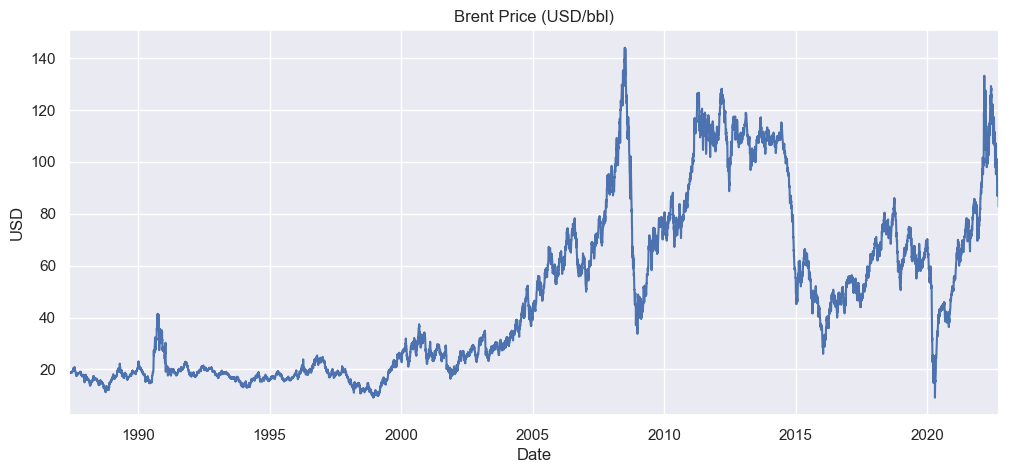

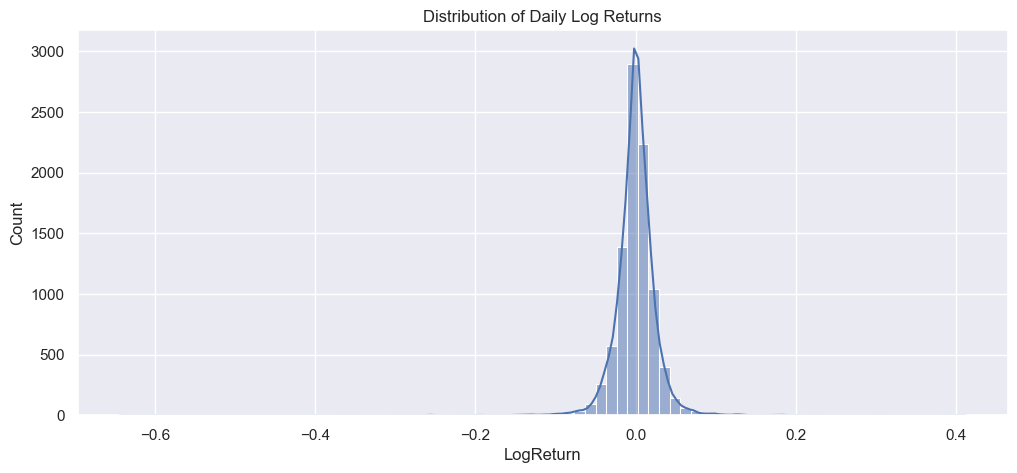

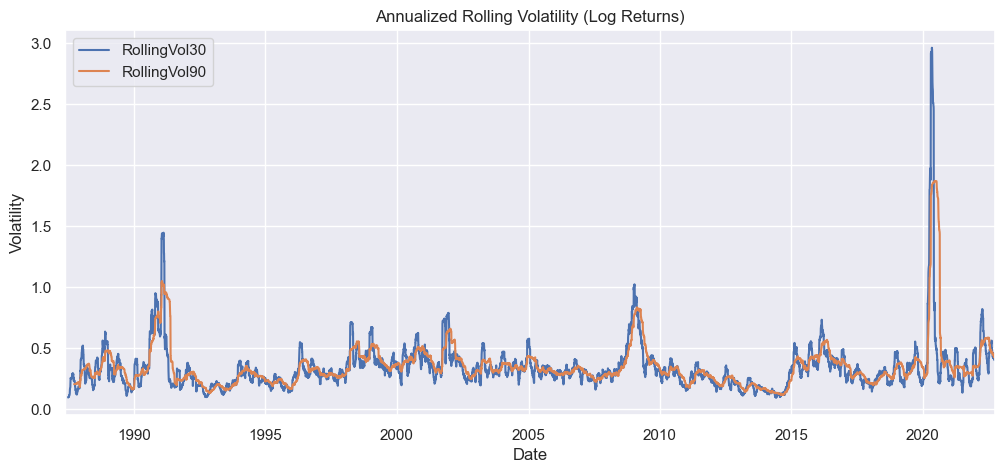

,count,mean,std,min,25%,50%,75%,max
Price,9228.0,48.358367,32.923268,9.100000,19.030000,38.33,69.952500,143.950000
LogReturn,9227.0,0.000169,0.025215,-0.643699,-0.010765,0.00,0.011737,0.412023


In [ ]:
prices["LogPrice"] = np.log(prices["Price"])
prices["LogReturn"] = prices["LogPrice"].diff()
prices["RollingVol30"] = prices["LogReturn"].rolling(30).std() * np.sqrt(252)
prices["RollingVol90"] = prices["LogReturn"].rolling(90).std() * np.sqrt(252)

figures = {}

fig_trend, ax = plt.subplots()
prices["Price"].plot(ax=ax, title="Brent Price (USD/bbl)")
ax.set_ylabel("USD")
figures["price_trend"] = fig_trend
plt.show()

fig_ret, ax = plt.subplots()
sns.histplot(prices["LogReturn"].dropna(), bins=80, kde=True, ax=ax)
ax.set_title("Distribution of Daily Log Returns")
figures["return_hist"] = fig_ret
plt.show()

fig_vol, ax = plt.subplots()
prices[["RollingVol30", "RollingVol90"]].plot(ax=ax, title="Annualized Rolling Volatility (Log Returns)")
ax.set_ylabel("Volatility")
figures["rolling_vol"] = fig_vol
plt.show()

summary_stats = prices[["Price", "LogReturn"]].describe().T
summary_stats

# Data quality snapshot
data_quality = {
    "missing_price": int(prices["Price"].isna().sum()),
    "missing_log_return": int(prices["LogReturn"].isna().sum()),
    "duplicate_dates": int(prices.index.duplicated().sum()),
    "coverage_start": str(prices.index.min().date()),
    "coverage_end": str(prices.index.max().date()),
}
data_quality

# Stationarity diagnostics (skip gracefully if statsmodels isn't available)
try:
    from statsmodels.tsa.stattools import adfuller, kpss

    log_returns = prices["LogReturn"].dropna()
    adf_stat, adf_p, *_ = adfuller(log_returns)
    kpss_stat, kpss_p, *_ = kpss(log_returns, regression="c", nlags="auto")
    stationarity = {
        "adf_stat": float(adf_stat),
        "adf_pvalue": float(adf_p),
        "kpss_stat": float(kpss_stat),
        "kpss_pvalue": float(kpss_p),
    }
except Exception as exc:
    stationarity = {"error": f"Stationarity tests unavailable: {exc}"}

stationarity

## 4. Baseline PyMC change-point specification
Model a single structural break using a discrete uniform prior over the full history. The observation model switches between two means with a shared standard deviation.

In [18]:
price_array = prices["Price"].to_numpy()
time_idx = np.arange(len(price_array))
coords = {"time": prices.index}

with pm.Model(coords=coords) as cp_model:
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(price_array) - 1)
    mu_before = pm.Normal("mu_before", mu=price_array.mean(), sigma=40)
    mu_after = pm.Normal("mu_after", mu=price_array.mean(), sigma=40)
    sigma = pm.HalfNormal("sigma", sigma=25)

    mean_switch = pm.math.switch(pm.math.le(time_idx, tau), mu_before, mu_after)
    pm.Normal("obs", mu=mean_switch, sigma=sigma, observed=price_array, dims="time")

    cp_trace = pm.sample(1000, tune=1000, target_accept=0.9, random_seed=42, progressbar=True)

cp_trace

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_before, mu_after, sigma]


c:\Users\alexo\Desktop\File\10Academy\week11\Github\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

: 

## 5. Posterior sampling diagnostics and event comparison
Interrogate sampler health, summarize the posterior over `tau`, and align the highest-probability change dates with the curated event catalog.

In [ ]:
posterior_summary = az.summary(cp_trace, var_names=["mu_before", "mu_after", "sigma", "tau"])
posterior_summary

diagnostics = {
    "rhat": az.rhat(cp_trace, var_names=["mu_before", "mu_after", "sigma", "tau"]).to_dict(),
    "ess": az.ess(cp_trace, var_names=["mu_before", "mu_after", "sigma", "tau"]).to_dict()
}
diagnostics


In [ ]:
az.plot_trace(cp_trace, var_names=["mu_before", "mu_after", "sigma", "tau"], compact=True);
plt.show()


In [ ]:
tau_samples = cp_trace.posterior["tau"].values.flatten().astype(int)
tau_mode = np.bincount(tau_samples).argmax()
tau_date = prices.index[tau_mode]
mu_before_est = cp_trace.posterior["mu_before"].mean().item()
mu_after_est = cp_trace.posterior["mu_after"].mean().item()

print(f"Most probable change point index: {tau_mode} => date {tau_date.date()}")
print(f"Mean shift: {mu_before_est:.2f} → {mu_after_est:.2f} USD/bbl ({(mu_after_est/mu_before_est - 1)*100:.1f}% change)")

fig_cp, ax = plt.subplots()
prices["Price"].plot(ax=ax, label="Price", alpha=0.7)
ax.axvline(tau_date, color="red", linestyle="--", linewidth=2, label=f"Model τ ({tau_date.date()})")
ax.set_ylabel("USD/bbl")
ax.set_title("Detected change point vs. price history")

events_path = DATA_DIR / "events_catalog.csv"
try:
    events = pd.read_csv(events_path, parse_dates=["Date"])
except FileNotFoundError:
    events = pd.DataFrame(columns=["Date", "Event_Name", "Category", "Hypothesized_Impact"])
    print("Events catalog not found; skipping event overlay.")

if not events.empty:
    for _, row in events.iterrows():
        ax.axvline(row["Date"], color="gray", alpha=0.15)
ax.legend()
plt.show()

if events.empty:
    comparison = pd.DataFrame(columns=["Date", "Event_Name", "Category", "Hypothesized_Impact", "Days_From_Tau", "Abs_Diff"])
else:
    comparison = events.assign(
        Days_From_Tau=(events["Date"] - tau_date).dt.days,
        Abs_Diff=lambda df: df["Days_From_Tau"].abs()
    ).sort_values("Abs_Diff")
comparison.head(10)

## 6. Flask endpoint scaffolding for React dashboard integration
Expose notebook artifacts via lightweight Flask routes so the React SPA can query the latest change point summaries without re-running notebooks.

In [ ]:
import json

# Prepare the results dictionary
results = {
    "run_ts": run_ts,
    "tau_index": int(tau_mode),
    "tau_date": tau_date.strftime("%Y-%m-%d"),
    "mu_before": float(mu_before_est),
    "mu_after": float(mu_after_est),
    "mean_shift_pct": float((mu_after_est / mu_before_est - 1) * 100),
    "posterior_summary": posterior_summary.to_dict(),
    "diagnostics": diagnostics,
    "summary_stats": summary_stats.to_dict(),
    "data_quality": data_quality,
    "stationarity": stationarity,
    "event_matches": comparison.head(10).to_dict(orient="records"),
    "data_files": ARTIFACTS
}

# Save to JSON for the external Dashboard to pick up
results_path = DATA_DIR / "analysis_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Analysis results saved to {results_path}")
print("You can now start the external Flask backend to serve this data.")